In [6]:
import xarray as xr
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [7]:
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.375, -60.0, -44.875]
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2023-12-31")

fishing_ds = xr.open_dataset("../data/processed/dynamic/HKP.nc")

fishing = fishing_ds["PesoTotal"]
fishing_presence = (fishing > 0).astype(int)
fishing_presence = fishing_presence.fillna(0)

# fishing = (fishing - fishing.mean()) / fishing.std()
fishing = fishing/1000
# fishing = np.log1p(fishing)
fishing = fishing.fillna(0)


temp_ds = xr.open_dataset("../data/processed/dynamic/to_surface.nc")
temp = temp_ds["to"]
temp = (temp - temp.mean()) / temp.std()
temp = temp.fillna(0)

temp_lag1 = temp.shift(time=1).fillna(0)
temp_lag2 = temp.shift(time=2).fillna(0)

temp_bottom_ds = xr.open_dataset("../data/processed/dynamic/temp_bottom.nc")
temp_bottom = temp_bottom_ds["to"]
temp_bottom = (temp_bottom - temp_bottom.mean()) / temp_bottom.std()
temp_bottom = temp_bottom.fillna(0)

temp_bottom_lag1 = temp_bottom.shift(time=1).fillna(0)

chl_ds = xr.open_dataset("../data/processed/dynamic/chl.nc")
chl = chl_ds["CHL"]
chl = (chl - chl.mean()) / chl.std()
chl = chl.fillna(0)

chl_lag1 = chl.shift(time=1).fillna(0)

mixed_ds = xr.open_dataset("../data/processed/dynamic/mixed_layer.nc")
mixed = mixed_ds["mlotst"]
mixed = (mixed - mixed.mean()) / mixed.std()
mixed = mixed.fillna(0)

mixed_lag1 = mixed.shift(time=1).fillna(0)

depth_ds = xr.open_dataset("../data/processed/static/depth.nc")
depth = depth_ds["depth"] 
depth = (depth - depth.mean()) / depth.std()
depth = depth.fillna(0)
depth = depth.broadcast_like(temp)

zo_ds = xr.open_dataset("../data/processed/dynamic/zo_surface.nc")
zo = zo_ds["zo"]
zo = (zo - zo.mean()) / zo.std()
zo = zo.fillna(0)

so_ds = xr.open_dataset("../data/processed/dynamic/so_surface.nc")
so = so_ds["so"]
so = (so - so.mean()) / so.std()
so = so.fillna(0)

mask_ds = xr.open_dataset("../data/processed/static/fishing_area_mask.nc")
mask = mask_ds["mask"]
mask = mask.broadcast_like(temp)

month = temp["time"].dt.month
month_sin = np.sin(2 * np.pi * month / 12)
month_cos = np.cos(2 * np.pi * month / 12)
month_sin = month_sin.broadcast_like(temp)
month_cos = month_cos.broadcast_like(temp)
month = month.broadcast_like(temp)

year = temp["time"].dt.year
year = (year - year.mean()) / year.std()
year = year.broadcast_like(temp)

lat = (temp["lat"] - temp["lat"].mean()) / temp["lat"].std()
lon = (temp["lon"] - temp["lon"].mean()) / temp["lon"].std()
lat = lat.broadcast_like(temp)
lon = lon.broadcast_like(temp) #se añade como dinámica porque ya se ha corregido la forma

temp, temp_bottom, chl, mixed, fishing, mask, depth, month_sin, month_cos, lat, lon, zo, so, month, year, temp_lag1, mixed_lag1, temp_bottom_lag1, chl_lag1, fishing_presence, temp_lag2 = xr.align(temp, temp_bottom, chl, mixed, fishing, mask, depth, month_sin, month_cos, lat, lon, zo, so, month, year, temp_lag1, mixed_lag1, temp_bottom_lag1, chl_lag1, fishing_presence, temp_lag2, join="inner")

cropped = lambda da: da.sel(
    lon=slice(min_lon-1, max_lon+1),
    lat=slice(min_lat-2, max_lat),
    time=slice(min_time, max_time)
)

cropped1 = lambda da: da.sel(
    lon=slice(min_lon, max_lon),
    lat=slice(min_lat, max_lat),
    time=slice(min_time, max_time)
)

fishing = cropped1(fishing)
fishing_presence = cropped1(fishing_presence)

temp = cropped(temp)
temp_bottom = cropped(temp_bottom)
chl = cropped(chl)
mixed = cropped(mixed)
mixed_lag1 = cropped(mixed_lag1)

mask = cropped(mask)
depth = cropped(depth)
zo = cropped(zo)
so = cropped(so)
month = cropped(month)
month_sin = cropped(month_sin)
month_cos = cropped(month_cos)
lat = cropped(lat)
lon = cropped(lon)
year = cropped(year)
temp_lag1 = cropped(temp_lag1)
temp_bottom_lag1 = cropped(temp_bottom_lag1)
chl_lag1 = cropped(chl_lag1)

temp_lag2 = cropped(temp_lag2)


In [8]:
vars_ = [temp,temp_bottom, chl, depth, zo, so, mixed, 
        #  temp_lag1, temp_bottom_lag1, chl_lag1, mixed_lag1,
         year, month_sin, month_cos
         ]
in_channels = len(vars_)
X = xr.concat(vars_, dim="channel")
X = X.transpose("time", "channel", "lat", "lon")

y = fishing  # (time, lat, lon)
y = y.transpose("time", "lat", "lon")

m = mask
m = m.transpose("time", "lat", "lon")

split_year = 2020

train_X = X.sel(time=slice(None, f"{split_year-1}-12-31"))
test_X  = X.sel(time=slice(f"{split_year}-01-01", None))

train_y = y.sel(time=slice(None, f"{split_year-1}-12-31"))
test_y  = y.sel(time=slice(f"{split_year}-01-01", None))

train_m = m.sel(time=slice(None, f"{split_year-1}-12-31"))
test_m  = m.sel(time=slice(f"{split_year}-01-01", None))

train_m_out = train_m.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))
test_m_out = test_m.sel(lat=slice(min_lat, max_lat), lon=slice(min_lon, max_lon))

def create_windows(X, y, m, m_out, window=10):
    X_data = X.values   # (time, channels, H, W)
    y_data = y.values   # (time, H, W)
    m_data = m.values   # (time, H, W)
    m_out_data = m_out.values   # (time, H, W)

    X_seq, y_seq, m_seq, m_out_seq = [], [], [], []

    for i in range(len(X_data) - window):
        X_seq.append(X_data[i:i+window])
        y_seq.append(y_data[i+window])
        m_seq.append(m_data[i+window])
        m_out_seq.append(m_out_data[i+window])
        

    return (
        torch.tensor(np.stack(X_seq), dtype=torch.float32),
        torch.tensor(np.stack(y_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_seq), dtype=torch.float32),
        torch.tensor(np.stack(m_out_seq), dtype=torch.float32)
    )

window = 12

X_train, y_train, m_train, m_out_train = create_windows(train_X, train_y, train_m, train_m_out, window)
X_test, y_test, m_test, m_out_test = create_windows(test_X, test_y, test_m, test_m_out, window)

print(X_train.shape)  # (N, T, C, H, W)
print(y_train.shape)  # (N, H, W)
print(m_train.shape)  # (N, H, W)
print(m_out_train.shape)  # (N, H, W)
###### Data Loaders ######
batch_size = 24

train_loader = DataLoader(
    TensorDataset(X_train, y_train, m_train, m_out_train),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test, m_test, m_out_test),
    batch_size=batch_size,
    shuffle=False
)


torch.Size([72, 12, 10, 37, 24])
torch.Size([72, 21, 8])
torch.Size([72, 37, 24])
torch.Size([72, 21, 8])


In [9]:
# -------- Conv Block --------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout3d(0.2),
            nn.Conv3d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
            )


    def forward(self, x):
        return self.block(x)

# -------- U-Net 3D --------
class UNet3D(nn.Module):
    def __init__(self, in_channels, out_channels=1, base_ch=8):
        super().__init__()

        # -------- Encoder --------
        self.enc1 = ConvBlock(in_channels, base_ch)
        self.pool1 = nn.MaxPool3d((1,2,2))

        self.enc2 = ConvBlock(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d((1,2,2))

        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)
        self.pool3 = nn.MaxPool3d((1,2,2))

        # -------- Bottleneck --------
        self.bottleneck = ConvBlock(base_ch * 4, base_ch * 4)

        # -------- Decoder --------
        self.up3 = nn.ConvTranspose3d(base_ch * 4, base_ch * 4, (1,2,2), stride=(1,2,2))
        self.dec3 = ConvBlock(base_ch * 8, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, (1,2,2), stride=(1,2,2))
        self.dec2 = ConvBlock(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, (1,2,2), stride=(1,2,2))
        self.dec1 = ConvBlock(base_ch * 2, base_ch)

        self.final_conv = nn.Conv3d(base_ch, out_channels, 1)

        self.temporal_attn = nn.Conv3d(1, 1, kernel_size=(3,1,1), padding=(1,0,0))

    def forward(self, x):
        # INPUT COMES AS:
        # (B, T, C, H, W)

        # Convert to:
        # (B, C, T, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        # Encoder
        s1 = self.enc1(x)
        p1 = self.pool1(s1)
        s2 = self.enc2(p1)
        p2 = self.pool2(s2)
        s3 = self.enc3(p2)
        p3 = self.pool3(s3)

        # Bottleneck
        b = self.bottleneck(p3)

        # Decoder
        d3 = self.up3(b)
        d3 = F.interpolate(d3, size=s3.shape[2:], mode='trilinear', align_corners=False)
        d3 = torch.cat([d3, s3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = F.interpolate(d2, size=s2.shape[2:], mode='trilinear', align_corners=False)
        d2 = torch.cat([d2, s2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=s1.shape[2:], mode='trilinear', align_corners=False)
        d1 = torch.cat([d1, s1], dim=1)
        d1 = self.dec1(d1)

        out = self.final_conv(d1)

        attn = torch.sigmoid(self.temporal_attn(out.mean(dim=1, keepdim=True)))
        out = out * attn
        out = out.mean(dim=2)

        out = F.interpolate(out, size=(21, 8), mode="bilinear", align_corners=False) #hardcoded y lat and lon size

        return out
    
def masked_mse_loss(pred, target, mask, weight_factor=5):
    """
    pred:   (B, 1, H, W)
    target: (B, H, W)
    mask:   (B, H, W)
    """

    target = target.unsqueeze(1)   # -> (B,1,H,W)
    mask = mask.unsqueeze(1).float()
    weights = 1.0 + weight_factor * mask
    loss = (pred - target) ** 2
    loss = loss * weights
    return loss.mean()

Epoch 1/1000 | Loss: 13907.9382 | Train R2: -0.1336 | Test R2: -0.1750
Epoch 2/1000 | Loss: 13890.8714 | Train R2: -0.1320 | Test R2: -0.1750
Epoch 3/1000 | Loss: 13871.9033 | Train R2: -0.1304 | Test R2: -0.1747
Epoch 4/1000 | Loss: 13859.4744 | Train R2: -0.1293 | Test R2: -0.1739
Epoch 5/1000 | Loss: 13853.4473 | Train R2: -0.1287 | Test R2: -0.1724
Epoch 6/1000 | Loss: 13848.6911 | Train R2: -0.1283 | Test R2: -0.1707
Epoch 7/1000 | Loss: 13844.5706 | Train R2: -0.1279 | Test R2: -0.1698
Epoch 8/1000 | Loss: 13841.9531 | Train R2: -0.1277 | Test R2: -0.1697
Epoch 9/1000 | Loss: 13839.6527 | Train R2: -0.1275 | Test R2: -0.1699
Epoch 10/1000 | Loss: 13837.1921 | Train R2: -0.1272 | Test R2: -0.1689
Epoch 11/1000 | Loss: 13834.3193 | Train R2: -0.1270 | Test R2: -0.1688
Epoch 12/1000 | Loss: 13832.5199 | Train R2: -0.1268 | Test R2: -0.1689
Epoch 13/1000 | Loss: 13830.5716 | Train R2: -0.1267 | Test R2: -0.1686
Epoch 14/1000 | Loss: 13826.3753 | Train R2: -0.1263 | Test R2: -0.1681
E

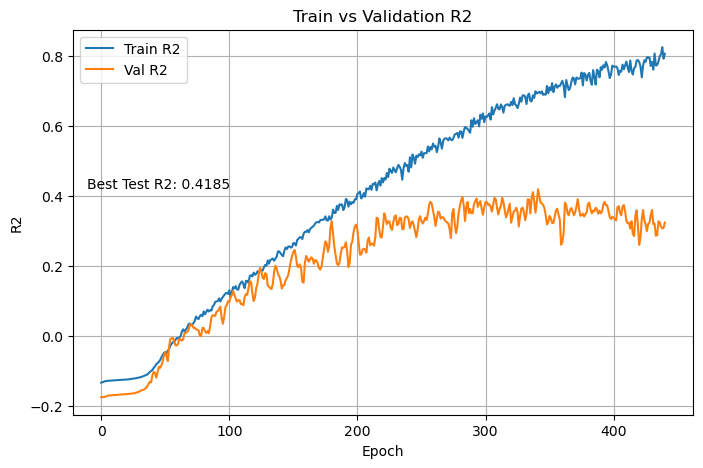

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet3D(in_channels=in_channels).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_test_r2 = -float("inf")
best_train_r2 = -float("inf")

patience = 100
epochs = 1000
counter = 0

train_r2_history = []
val_r2_history = []

for epoch in range(epochs):

    # -------- Training --------
    model.train()

    total_loss = 0

    train_preds = []
    train_targets = []

    for x, y, m, m_out in train_loader:

        x = x.to(device)          # (B,T,C,H,W)
        y = y.to(device)          # (B,H,W)
        # m = m.to(device)          # (B,H,W)
        m_out = m_out.to(device)  # (B,H,W)

        optimizer.zero_grad()

        pred = model(x)           # (B,1,H,W)

        loss = masked_mse_loss(pred, y, m_out)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # -------- R2 only over masked ocean points --------
        mask_flat = m_out.detach().cpu().view(-1) > 0

        pred_flat = pred.detach().cpu().squeeze(1).view(-1)
        target_flat = y.detach().cpu().view(-1)

        train_preds.append(pred_flat[mask_flat])
        train_targets.append(target_flat[mask_flat])

    train_preds = torch.cat(train_preds).numpy()
    train_targets = torch.cat(train_targets).numpy()

    r2 = r2_score(train_targets, train_preds)

    # -------- Validation --------
    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():

        for x, y, m, m_out in test_loader:

            x = x.to(device)
            y = y.to(device)
            # m = m.to(device)
            m_out = m_out.to(device)

            pred = model(x)

            mask_flat = m_out.cpu().view(-1) > 0

            pred_flat = pred.cpu().squeeze(1).view(-1)
            target_flat = y.cpu().view(-1)

            test_preds.append(pred_flat[mask_flat])
            test_targets.append(target_flat[mask_flat])

    test_preds = torch.cat(test_preds).numpy()
    test_targets = torch.cat(test_targets).numpy()
    
    test_r2 = r2_score(test_targets, test_preds)

    # -------- Early stopping --------
    improved = False

    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        improved = True

    if improved:
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping")
        break

    print(f"Epoch {epoch+1}/{epochs} | "f"Loss: {total_loss/len(train_loader):.4f} | "f"Train R2: {r2:.4f} | "f"Test R2: {test_r2:.4f}")

    train_r2_history.append(r2)
    val_r2_history.append(test_r2)

# -------- Plot --------
plt.figure(figsize=(8,5))

plt.plot(train_r2_history, label="Train R2")
plt.plot(val_r2_history, label="Val R2")

plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title("Train vs Validation R2")
plt.annotate(f"Best Test R2: {best_test_r2:.4f}", xy=(0, best_test_r2), xytext=(-10, best_test_r2), textcoords="offset points")

plt.legend()
plt.grid(True)

plt.show()

